# Fine-tuning médical — TinyLlama 1.1B

**Projet :** TechCorp IA — Mission Expérimentale R&D  
**Modèle :** `TinyLlama/TinyLlama-1.1B-Chat-v1.0`  
**Dataset :** `ruslanmv/ai-medical-chatbot` (HuggingFace)  
**Méthode :** LoRA via HuggingFace PEFT  

> ⚠️ Ce modèle est expérimental — pas pour production médicale.

## Étape 1 — Installation des dépendances

In [1]:
!pip install -q transformers peft datasets accelerate trl matplotlib torchao --upgrade

## Étape 2 — Vérification du GPU

In [2]:
import torch

print(f"GPU disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️ Aucun GPU détecté — active le GPU dans Exécution > Modifier le type d'exécution")

GPU disponible : True
GPU : Tesla T4
VRAM : 15.6 GB


## Étape 3 — Chargement du modèle TinyLlama

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
)

print(f"✅ Modèle chargé : {MODEL_NAME}")
print(f"Paramètres : {sum(p.numel() for p in model.parameters()) / 1e9:.2f}B")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Modèle chargé : TinyLlama/TinyLlama-1.1B-Chat-v1.0
Paramètres : 1.10B


## Étape 4 — Configuration LoRA

In [4]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


## Étape 5 — Chargement et préparation du dataset médical

In [14]:
from datasets import load_dataset

NUM_SAMPLES = 500

raw_dataset = load_dataset("ruslanmv/ai-medical-chatbot", split="train")
print(f"Dataset complet : {len(raw_dataset)} exemples")
print(f"Colonnes : {raw_dataset.column_names}")

dataset = raw_dataset.shuffle(seed=42).select(range(NUM_SAMPLES))
print(f"Sous-ensemble utilisé : {len(dataset)} exemples")
print("\nExemple :")
print(f"Patient : {dataset[0]['Patient'][:150]}")
print(f"Doctor  : {dataset[0]['Doctor'][:150]}")

Dataset complet : 256916 exemples
Colonnes : ['Description', 'Patient', 'Doctor']
Sous-ensemble utilisé : 500 exemples

Exemple :
Patient : last year my wife was went through a surgery for appendix cancer, that appendix was removed , that appendix slice tested in lab and found so called ad
Doctor  : Hi and welcome to HCM. First, you dont have to worry. This cant be tumour relaps because this is lesion in abdominall wall,obviously some local infect


In [15]:
SYSTEM_PROMPT = "You are a helpful medical assistant. Provide clear, accurate and cautious medical information."

def format_conversation(example):
    text = (
        f"<|system|>\n{SYSTEM_PROMPT}</s>\n"
        f"<|user|>\n{example['Patient']}</s>\n"
        f"<|assistant|>\n{example['Doctor']}</s>"
    )
    return {"text": text}

dataset = dataset.map(format_conversation, remove_columns=dataset.column_names)

split = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split["train"]
eval_dataset  = split["test"]

print(f"Train : {len(train_dataset)} | Eval : {len(eval_dataset)}")
print("\nExemple formaté :")
print(train_dataset[0]["text"][:400])

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train : 450 | Eval : 50

Exemple formaté :
<|system|>
You are a helpful medical assistant. Provide clear, accurate and cautious medical information.</s>
<|user|>
Hello, i have reoccurring small dots like the end of a biro on my right foot only. They come ovr a week or 10 days, become itchy and when itched fill with fluid like a blister. i have them aroung the heel and down the right side of the foot and between my big toe. after they have 


## Étape 6 — Entraînement

In [16]:
from trl import SFTTrainer, SFTConfig

training_args = SFTConfig(
    output_dir="./tinyllama-medical-lora",
    num_train_epochs=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_steps=50,
    logging_steps=25,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True,
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
)

print("🚀 Démarrage de l'entraînement...")
train_result = trainer.train()
print("✅ Entraînement terminé !")

Adding EOS to train dataset:   0%|          | 0/450 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/450 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/450 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/50 [00:00<?, ? examples/s]

🚀 Démarrage de l'entraînement...


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,2.151128,2.162235,2.128405,134956.000000,0.542166


✅ Entraînement terminé !


## Étape 7 — Métriques et courbe de loss

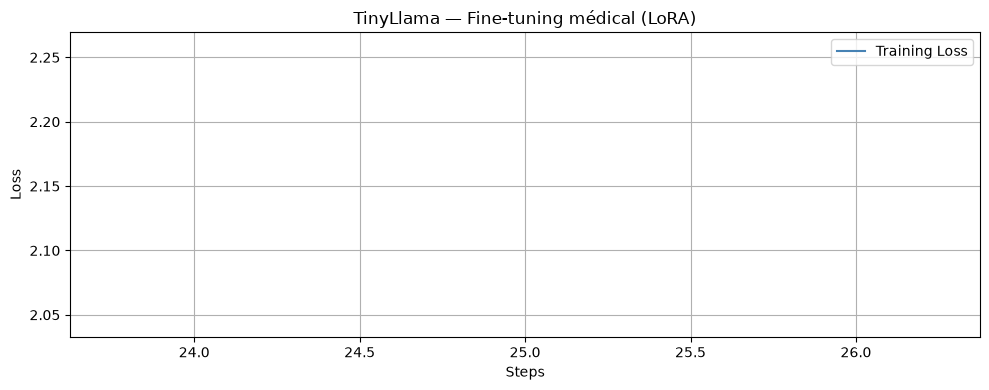


=== Résumé de l'entraînement ===
Loss initiale  : 2.1511
Loss finale    : 2.1511
Amélioration   : 0.0%
Steps total    : 29
Temps total    : 131s


In [19]:
import matplotlib.pyplot as plt

logs = [log for log in trainer.state.log_history if "loss" in log]
steps = [l["step"] for l in logs]
losses = [l["loss"] for l in logs]

plt.figure(figsize=(10, 4))
plt.plot(steps, losses, label="Training Loss", color="steelblue")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("TinyLlama — Fine-tuning médical (LoRA)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

print("\n=== Résumé de l'entraînement ===")
print(f"Loss initiale  : {losses[0]:.4f}")
print(f"Loss finale    : {losses[-1]:.4f}")
print(f"Amélioration   : {(losses[0] - losses[-1]) / losses[0] * 100:.1f}%")
print(f"Steps total    : {train_result.global_step}")
print(f"Temps total    : {train_result.metrics['train_runtime']:.0f}s")

## Étape 8 — Test du modèle fine-tuné

In [20]:
TEST_QUESTIONS = [
    "What are the symptoms of diabetes?",
    "I have a headache and fever since 2 days, what should I do?",
    "What is the difference between a cold and the flu?",
]

model.eval()
for question in TEST_QUESTIONS:
    prompt = (
        f"<|system|>\n{SYSTEM_PROMPT}</s>\n"
        f"<|user|>\n{question}</s>\n"
        f"<|assistant|>\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=200,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    response = tokenizer.decode(outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    print(f"Q: {question}")
    print(f"A: {response.strip()}")
    print("-" * 60)

[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What are the symptoms of diabetes?
A: Hello. Welcome to HCM. Diabetes mellitus is a metabolic disease with glucose dysregulation due to impaired insulin secretion or insulin resistance. The symptoms are multi-systemic hyperglycemia, polyuria, polydipsia, weight gain, fatigue, hypertension, hypertriglyceridemia, and hyperlipidemia. Insulin resistance occurs due to multiple factors like genetics, obesity, and metabolic syndrome. Insulin resistance is the most common cause of diabetes. Insulin resistance is due to a combination of dysfunction of the pancreas, inadequate glucose control, and intra-cellular storage of glucose. As per your history, you are a smoker and overweight. This is a clear indication of diabetes. You should reduce your weight
------------------------------------------------------------


[transformers] Both `max_new_tokens` (=200) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: I have a headache and fever since 2 days, what should I do?
A: Hello, I have gone through your question. I can understand your concern.  If you do not have fever then nothing to worry.  The most common causes of headache and fever are  infection and sinusitis. Both can be treated with antibiotic and cough syrup.  But for fever, I would suggest to consult your doctor to get the necessary investigations done like complete blood count, urine culture and sensitivity.  Consult your doctor and take care. Hope I have answered your query. Let me know if I can assist you further. Regards, Dr. Renuka Nayak, General & Family Physician
------------------------------------------------------------
Q: What is the difference between a cold and the flu?
A: Hello, In general, cold is not a serious condition and you can treat it with over the counter medications like tussin and loratadine. Or you can take an antihistamine to relieve the symptoms of watery eyes and runny nose. It is not a life threaten

## Étape 9 — Sauvegarde du modèle

In [21]:
trainer.save_model("./tinyllama-medical-lora")
tokenizer.save_pretrained("./tinyllama-medical-lora")
print("✅ Modèle sauvegardé dans ./tinyllama-medical-lora")
print("\n📋 Pour partager : File > Share dans Colab, puis copiez le lien.")

✅ Modèle sauvegardé dans ./tinyllama-medical-lora

📋 Pour partager : File > Share dans Colab, puis copiez le lien.
